In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
dataset = loadmat('face_emotion_data.mat')

X, y = dataset['X'], dataset['y']
n, p = np.shape(X)

y[y==-1]=0
X = np.hstack((np.ones((n,1)), X))  # append a column of ones

# Question 1a

In [19]:
# parameters 
def logsig(_x):
    return 1/(1+np.exp(-_x))

# training parameters
def train(index):
    Xb = X[index]
    Y = y[index]
    n, p = np.shape(Xb)
    V = np.random.randn(M + 1, 1)
    W = np.random.randn(p, M)
    
    training_error = [] # initialize training error
    
    # training error
    for epoch in range(L):
        indices = np.random.permutation(n)
        for i in indices:
            H = logsig(np.hstack((np.ones((1, 1)), Xb[[i], :] @ W))) 
            Y_hat = logsig(H @ V)
            delta = (Y_hat - Y[[i], :]) * Y_hat * (1 - Y_hat)
            V_new = V - a * H.T @ delta
            gamma = delta @ V[1:, :].T * H[:, 1:] * (1 - H[:, 1:])
            W_new = W - a * Xb[[i], :].T @ gamma
            
            V = V_new
            W = W_new
            
        H = logsig(np.hstack((np.ones((n, 1)), Xb @ W)))
        Y_hat = logsig(H @ V)
        training_error.append(np.mean(abs(np.round(Y_hat[:, 0]) - Y[:, 0])))
        
    return W, V, training_error

def test(W, V, indices):
    X_test = X[indices]
    y_test = y[indices]
    nt, _ = np.shape(X_test)
    
    H = logsig(np.hstack((np.ones((nt, 1)), X_test @ W)))
    Y_hat = logsig(H @ V)
    return np.mean(abs(np.round(Y_hat[:, 0]) - y_test[:, 0]))

            

# Question 1b

Text(0, 0.5, 'Training Error')

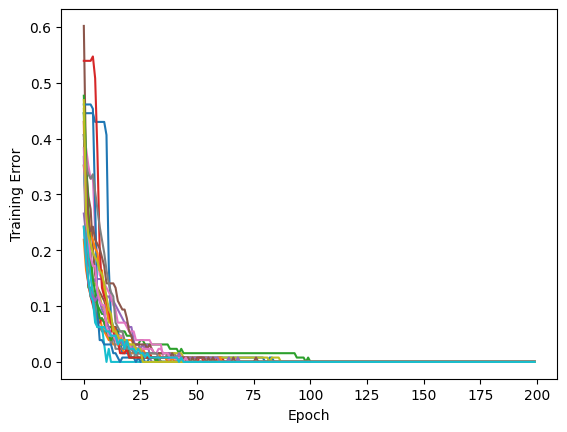

In [20]:
a = 0.05 
L = 200
M = 32 # neurons

for i in range(20):
    _,_,training_error = train(list(range(128)))
    plt.plot(training_error)
    
plt.xlabel('Epoch')
plt.ylabel('Training Error')

We can see that this classifier does achieve  0% error rate on the test set. The number of epochs (that are required to achieve 0% error rate) will depend on the run because it's random due to stochastic gradient descent. 

# Question 1c

In [21]:
a = 0.05
L = 200
M = 32

for ite in range(10):
    accuracy = []
    # 8-fold cross validation
    for i in range(8):
        test_ind = np.arange(i*16,(i+1)*16)
        train_ind = np.setdiff1d(np.arange(128),test_ind)
        W, V, training_error = train(train_ind)
        error = test(W,V, test_ind)
        accuracy.append(error)
    print(ite, "Test Accuracy:", np.mean(accuracy))


0 Test Accuracy: 0.03125
1 Test Accuracy: 0.0546875
2 Test Accuracy: 0.046875
3 Test Accuracy: 0.0390625
4 Test Accuracy: 0.0390625
5 Test Accuracy: 0.0390625
6 Test Accuracy: 0.046875
7 Test Accuracy: 0.0390625
8 Test Accuracy: 0.0390625
9 Test Accuracy: 0.03125


We can clearly see that from the test accuracy, we don't reach perfect accuracy for the classifier. We can also see that the accuracy varies a some amount for each iteration. 